## **Problem 1: Z-Score Method (Normal Data)**

Dataset (Age of students in a class):
[18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70]


Tasks:

Calculate the mean and standard deviation of Age.

Compute Z-Score for each value.

Identify outliers using |Z| > 3 conditions.

Remove those outliers and show the new dataset length.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

data = [18, 19, 20, 20, 21, 21, 22, 22, 23, 24,
        25, 26, 27, 28, 30, 32, 35, 40, 45, 70]

df = pd.DataFrame(data, columns=['Age'])

print(df)

mean_age = df['Age'].mean()

std_age=df['Age'].std()

print(f'the mean value is {mean_age}')
print(f'the std value is : {std_age}')

    Age
0    18
1    19
2    20
3    20
4    21
5    21
6    22
7    22
8    23
9    24
10   25
11   26
12   27
13   28
14   30
15   32
16   35
17   40
18   45
19   70
the mean value is 28.4
the std value is : 12.132600710482482


In [4]:
df['zscore_age']=(df['Age']-mean_age)/std_age # age er sob golare ak ak kore nia z_score ber korbe
df

,Age,zscore_age
0,18,-0.857195
1,19,-0.774772
2,20,-0.692349
3,20,-0.692349
4,21,-0.609927
5,21,-0.609927
6,22,-0.527504
7,22,-0.527504
8,23,-0.445082
9,24,-0.362659


In [ ]:
age_outliers=df[abs(df['zscore_age'])>3]

print(len(age_outliers))
display(age_outliers)


1


,Age,zscore_age
19,70,3.428778


In [6]:
df.drop(age_outliers.index, inplace=True, errors='ignore')

In [7]:
df

,Age,zscore_age
0,18,-0.857195
1,19,-0.774772
2,20,-0.692349
3,20,-0.692349
4,21,-0.609927
5,21,-0.609927
6,22,-0.527504
7,22,-0.527504
8,23,-0.445082
9,24,-0.362659


## **Problem 2: IQR Method (Skewed Data)**

Dataset (Monthly salaries in thousand BDT):

[25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]


Tasks:

Calculate Q1 (25th percentile) and Q3 (75th percentile).

Find IQR = Q3 - Q1.

Calculate lower bound and upper bound.

Identify outliers.

Cap (clip) the outliers to the bounds instead of deleting them.

Show min and max after capping.



In [8]:
data=[25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]
df=pd.DataFrame(data,columns=['salary'])
q1=df['salary'].quantile(0.25)
q3=df['salary'].quantile(0.75)
IQR=q3-q1
lower_bound = max(0,q1 - 1.5*IQR)   # -17.5 Astese tai age max(0,lower_bound)

upper_bound = q3 + 1.5*IQR
print(f'the lower bound is : {lower_bound}')
print(f'the upper bound is : {upper_bound}')

outliers=df[(df['salary']<lower_bound) | (df['salary']>upper_bound)]

print(f'the number of outliers is : {len(outliers)}')

display(outliers)

the lower bound is : 0
the upper bound is : 122.5
the number of outliers is : 4


,salary
21,150
22,200
23,250
24,500


In [9]:
df['salary']=df['salary'].clip(lower_bound,upper_bound)

In [10]:
df

,salary
0,25.0
1,28.0
2,30.0
3,32.0
4,32.0
5,33.0
6,35.0
7,35.0
8,36.0
9,38.0


## **Problem 3: Choose the Right Method**

Dataset A (Exam scores):
[55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]


Note: There are two very low scores (15, 20) and three high scores (100).
## **Dataset B (House prices in lakh BDT)**:

[30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200]


Tasks:

For Dataset A, plot a histogram (conceptually) – is it normal or skewed?

Which method (Z-Score or IQR) would you choose for Dataset A? Why?

For Dataset B, which method would you choose? Why?

Apply IQR on Dataset B and count how many outliers you get.

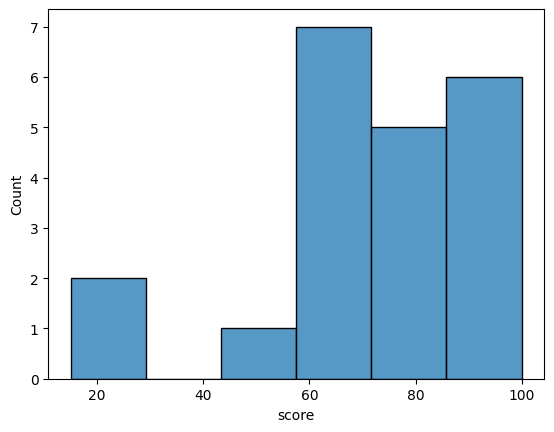

Q1: 62.0
Q3: 90.0
IQR: 28.0
Lower Bound: 20.0
Upper Bound: 132.0

Outliers:
    score
19     15

Outlier Count: 1


In [11]:
data= [55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]
df=pd.DataFrame(data,columns=['score'])
sns.histplot(df['score'])
plt.show()

# iqr method best

Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)


IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['score'] < lower_bound) | (df['score'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nOutliers:")
print(outliers)

print("\nOutlier Count:", len(outliers))



Dataset A is left-skewed (negatively skewed) due to the presence of very low scores (15, 20) and concentration of high values near 100.

 Therefore, the IQR method is more appropriate than Z-Score, because it does not assume normal distribution and is more robust to outliers.

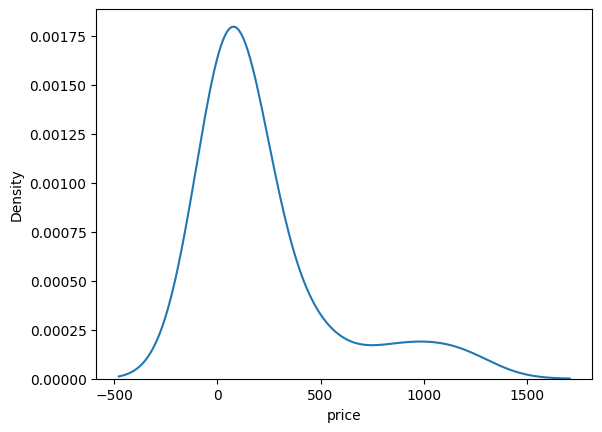

Q1: 45.0
Q3: 200.0
IQR: 155.0
Lower Bound: -187.5
Upper Bound: 432.5

Outliers:
    price
21    500
22    800
23   1000
24   1200

Outlier Count: 4


In [12]:
import pandas as pd

# Dataset B
data = [30, 32, 35, 38, 40, 42, 45, 48, 50, 55,
        60, 65, 70, 80, 90, 100, 120, 150, 200,
        300, 400, 500, 800, 1000, 1200]

df = pd.DataFrame(data, columns=['price'])
sns.kdeplot(df['price'])
plt.show()

# skewed right tai ami mone kori kde plot best hbe

# Step 1: Q1 and Q3
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

# Step 2: IQR
IQR = Q3 - Q1

# Step 3: Lower and Upper Bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 4: Detect outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Output
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nOutliers:")

print(outliers)

print("\nOutlier Count:", len(outliers))

,score
0,55
1,58
2,60
3,62
4,65
5,65
6,68
7,70
8,72
9,75


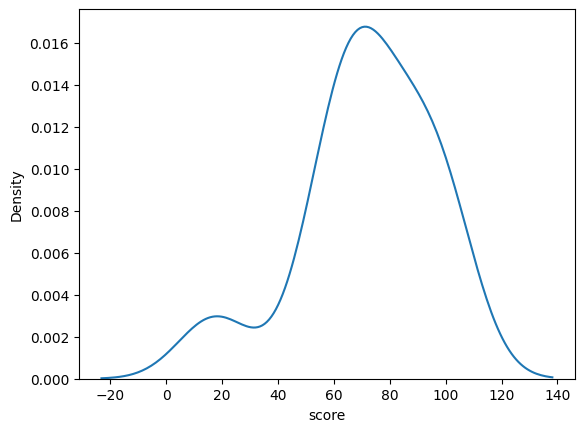

In [ ]:
data= [55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]
df=pd.DataFrame(data,columns=['score'])
display(df)

sns.kdeplot(df['score'])
plt.show()



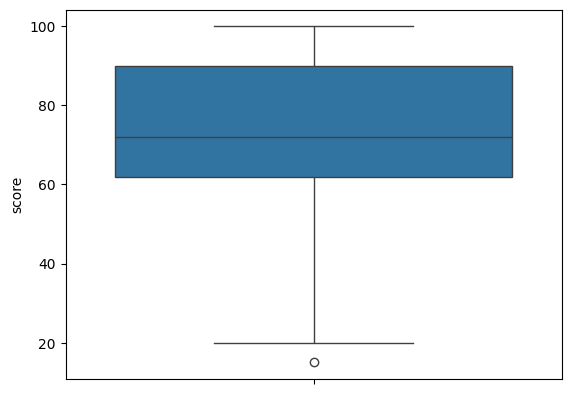

In [ ]:
sns.boxplot(df['score'])  # deken akane boxplot e kono outlier detect kora jacce na
plt.show()

In [ ]:
# ata extra korsi ami
# deken akane boxplot e kono outlier detect kora jacce na

df['score'].describe()



count     21.000000
mean      71.952381
std       23.408281
min       15.000000
25%       62.000000
50%       72.000000
75%       90.000000
max      100.000000
Name: score, dtype: float64

In [16]:
x=9
x=x/100
min_range=df['score'].quantile(x)
max_range=df['score'].quantile(1-x)
print(f'the min range is : {min_range}')
print(f'the max range is : {max_range}')


the min range is : 47.99999999999999
the max range is : 100.0


In [ ]:
df['score']=df['score'].clip(min_range,max_range)
df


C:\Users\Sayed\AppData\Local\Temp\ipykernel_17788\401425811.py:1: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['score']=df['score'].clip(min_range,max_range)


,score
0,55
1,58
2,60
3,62
4,65
5,65
6,68
7,70
8,72
9,75



## Problem 4: Winsorization (Percentile Method) **bold text**

Dataset (Product ratings out of 10):
[1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]

Tasks:

Use 5% Winsorization (x = 5, meaning cap at 5th and 95th percentiles).
Calculate 5th percentile and 95th percentile.

Cap all values below 5th percentile to the 5th percentile value.

Cap all values above 95th percentile to the 95th percentile value.

Show the min and max after Winsorization.

Explain why Winsorization is better than deletion here.


In [ ]:
data=[1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]
df=pd.DataFrame(data,columns=['Product rating'])

x=5
x=x/100
min_range=df['Product rating'].quantile(x)
max_range=df['Product rating'].quantile(1-x)

print(f'the min range is : {min_range}')
print(f'the max range is : {max_range}')


the min range is : 1.0
the max range is : 10.0


In [19]:
df['Product rating']=df['Product rating'].clip(min_range,max_range)
df


,Product rating
0,1.0
1,2.0
2,3.0
3,4.0
4,4.0
5,5.0
6,5.0
7,5.0
8,6.0
9,6.0


## **কেন Winsorization deletion এর চেয়ে better?**

## main couse: **bold text**

1..Deletion করলে:
data কমে যায়
information loss হয়
small dataset হলে problem
2..Winsorization করলে:
সব data থাকে
শুধু extreme value "limit" করা হয়
model বেশি stable হয়
skew কমে যায়

## **In one line**
 Deletion = data ফেলে দেওয়া
 Winsorization = extreme value কে cap করা


## **Problem 5: Mixed Methods – Compare Z-Score & IQR on Same Data **

**Dataset (Product ratings out of 10):**
[12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]


Tasks:
Plot a histogram (conceptually) and decide if the data is normal or skewed.

Apply Z-Score method (|Z| > 3) – count outliers and list them.

Apply IQR method (1.5×IQR) – count outliers and list them.

Which method found more outliers? Why?

Which method would you trust here? Justify.


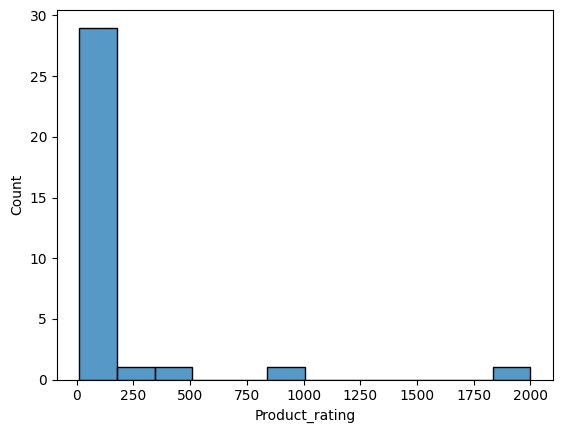

In [ ]:
data=[12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]
df=pd.DataFrame(data,columns=['Product_rating'])
sns.histplot(df['Product_rating'])
plt.show()


# skewed


In [21]:
rate_mean=df['Product_rating'].mean()
rate_std=df['Product_rating'].std()
print(f'the mean value is : {rate_mean}')
print(f'the std value is : {rate_std}')
df['zscore_rating']=(df['Product_rating']-rate_mean)/rate_std

df
# akne akto keyal kore dekhoo mean take nia ashse outliers er dike jeta onk boro sommassa
# protome value onek hower por oo mena ta outliers dike sore gese


the mean value is : 152.93939393939394
the std value is : 379.662180381614


,Product_rating,zscore_rating
0,12,-0.371223
1,15,-0.363321
2,18,-0.355420
3,20,-0.350152
4,22,-0.344884
5,22,-0.344884
6,23,-0.342250
7,24,-0.339616
8,25,-0.336982
9,25,-0.336982


In [22]:
outliers=df[abs(df['zscore_rating'])>3]
print(len(outliers))
display(outliers)
df.drop(outliers.index, inplace=True, errors='ignore')
df

1


,Product_rating,zscore_rating
32,2000,4.865011


,Product_rating,zscore_rating
0,12,-0.371223
1,15,-0.363321
2,18,-0.355420
3,20,-0.350152
4,22,-0.344884
5,22,-0.344884
6,23,-0.342250
7,24,-0.339616
8,25,-0.336982
9,25,-0.336982


In [23]:
q1=df['Product_rating'].quantile(0.25)
q3=df['Product_rating'].quantile(0.75)
IQR=q3-q1
lower_bound = max(0,q1 - 1.5*IQR) # -46.875

upper_bound = q3 + 1.5*IQR

print(f'the lower bound is : {lower_bound}')
print(f'the upper bound is : {upper_bound}')

outliers=df[(df['Product_rating']<lower_bound) | (df['Product_rating']>upper_bound)]

print(f'the number of outliers is : {len(outliers)}')
display(outliers)
df.drop(outliers.index,inplace=True,errors='ignore')
df
# akne dekho upper bound ta  144.125 and lower ta 0 ..so ata kono bad effect felbe na
# kaj e ..erpr ami ki korlam loer noicer goloa outliers and upper er porer golare
# outliers hisebe detect korsi


the lower bound is : 0
the upper bound is : 144.125
the number of outliers is : 4


,Product_rating,zscore_rating
28,150,-0.007742
29,200,0.123954
30,500,0.914130
31,1000,2.231090


,Product_rating,zscore_rating
0,12,-0.371223
1,15,-0.363321
2,18,-0.355420
3,20,-0.350152
4,22,-0.344884
5,22,-0.344884
6,23,-0.342250
7,24,-0.339616
8,25,-0.336982
9,25,-0.336982


# **1.. Why IQR is better**:

Dataset is highly skewed (right-skewed)
Z-score assumes normal distribution, which is not true here

Z-score mean & std are affected by extreme values
IQR uses median-based quartiles, so it is robust to outliers
IQR correctly detects extreme high values like 120, 500, 2000

# Final Conclusion: **bold text**

 Z-score = good for normal data
 IQR = best for skewed / real-world data

# **Problem 6: Real-World Scenario – Employee Bonus** # **Scenario: **

A company gives an annual bonus (in thousand BDT). HR wants to remove extreme outliers before calculating average bonus for policy making.

Dataset (Bonus amounts):
[5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]


Tasks:
Calculate mean, median, and mode. What do you observe?

Apply IQR method and find outliers.

Instead of deleting, apply Winsorization with x = 3 (i.e., cap at 3rd and 97th percentile).

Show the new min and max after Winsorization.

Calculate the new mean after Winsorization.
Is it more reasonable than the original mean?


In [24]:
import pandas as pd

df = pd.DataFrame(data, columns=['bonus'])

mean = df['bonus'].mean()
median = df['bonus'].median()
mode = df['bonus'].mode()      # 7,8,10 beshi ase

print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

Mean: 152.93939393939394
Median: 38.0
Mode: 0    22
1    25
Name: bonus, dtype: int64


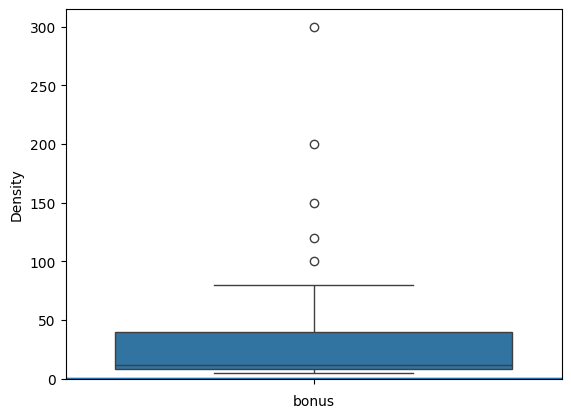

In [25]:
data=[5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]
df=pd.DataFrame(data,columns=['bonus'])
sns.kdeplot(df['bonus'])
sns.boxplot(df['bonus'])
plt.show()


In [26]:
q1 = df['bonus'].quantile(0.25)
q3 = df['bonus'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['bonus'] < lower) | (df['bonus'] > upper)]

print(outliers)

    bonus
28    100
29    120
30    150
31    200
32    300


In [ ]:
x=3
x=x/100

min_range = df['bonus'].quantile(x)
max_range = df['bonus'].quantile(1-x)
print(f'the min range is : {min_range}')
print(f'the max range is : {max_range}')

# clip korlam

df['bonus'] = df['bonus'].clip(min_range,max_range)
df


the min range is : 5.0
the max range is : 203.99999999999991


C:\Users\Sayed\AppData\Local\Temp\ipykernel_17788\535184447.py:10: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['bonus'] = df['bonus'].clip(min_range,max_range)


,bonus
0,5
1,5
2,6
3,6
4,7
5,7
6,7
7,8
8,8
9,8


In [28]:
print("Min after winsorization:", df['bonus'].min()) # disnsheshe winsor e kora quantile man golai
                                                    # khali akt dekaisi ora compare korte bolse tai
print("Max after winsorization:", df['bonus'].max())

Min after winsorization: 5
Max after winsorization: 204


# **Final Explanation (Exam Answer)**

# **What do you observe (Mean, Median, Mode)?**

👉 Mean is much higher than median because of extreme values
👉 Median is more stable
👉 Mode shows most frequent small-mid bonuses

So dataset is right-skewed

 Why IQR outliers?

1... IQR detects extreme bonuses like:

100
120
150
200
300

Because these are far from normal range.

# Winsorization result?

1.Instead of deleting:

Extreme values are capped
Data size remains same
No information loss

2. New mean vs old mean?

!! New mean becomes more realistic

 Old mean = inflated (because of 300, 200 etc.)
 New mean = stable and policy-friendly

 **Final Conclusion (write this in exam)**

 Winsorization is better here because:

It preserves all employees data
Reduces impact of extreme bonuses
Gives more realistic average for HR policy

 One-line memory:

 Deletion = lose data

 Winsorization = keep data + control extremes
  (BEST for HR/finance)